# Genetic Risk Prediction — Phase 2

## Genetic Inheritance and Clinical Annotation Analysis

Phase 2 integrates trio genotype information with Mendelian inheritance
features and clinical annotations.

The analysis examines:

- Parental and child genotype patterns
- Mendelian inheritance compatibility
- Inheritance source
- Possible child genotype outcomes
- Disease and clinical annotations
- HPO-based annotations
- Clinical interpretation of inherited variants

**Dataset:** `phase2_final_dataset.parquet`

ENVIRONMENT AND IMPORTS

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# DEFINE PATHS

DATA_PATH = Path("../data/phase2/phase2_final_dataset.parquet")
RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
DATA_OUTPUT_DIR = Path("../data/phase2")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOAD PHASE 2 DATASET

In [3]:
# LOAD DATASET

df_2 = pd.read_parquet(DATA_PATH)

print("Phase 2 dataset loaded successfully")
print("Shape:", df_2.shape)

Phase 2 dataset loaded successfully
Shape: (118609, 35)


DATASET OVERVIEW

In [4]:
# VIEW DATA

df_2.head()

,CHROM,POS,ID,REF,ALT,Mother_ID,Father_ID,Child_ID,Mother_GT,Father_GT,...,Mother_Carries_Alternate,Father_Carries_Alternate,Child_Carries_Alternate,Both_Parents_Carry_Alternate,Mendelian_Status,Inheritance_Source,Possible_Child_Dosages,_Disease_List,HPO_Count,HPO_Available
0,1,713442,rs3131987,T,C,NA12892,NA12891,NA12878,0/1,0/0,...,1,0,0,0,Compatible,Neither,"0,1",[],0,0
1,1,877831,rs6672356,T,C,NA12892,NA12891,NA12878,1/1,1/1,...,1,1,1,1,Compatible,Both,2,[],0,0
2,1,887560,rs3748595,A,C,NA12892,NA12891,NA12878,1/1,1/1,...,1,1,1,1,Compatible,Both,2,[],0,0
3,1,899937,rs143296006,G,T,NA12892,NA12891,NA12878,1/1,./.,...,1,0,0,0,Undetermined,Unknown,Unknown,[],0,0
4,1,899942,rs71509448,G,A,NA12892,NA12891,NA12878,1/1,./.,...,1,0,0,0,Undetermined,Unknown,Unknown,[],0,0


In [5]:
# VIEW COLUMNS

print("Number of columns:", len(df_2.columns))
print("\nColumns:")
print(df_2.columns.tolist())

Number of columns: 35

Columns:
['CHROM', 'POS', 'ID', 'REF', 'ALT', 'Mother_ID', 'Father_ID', 'Child_ID', 'Mother_GT', 'Father_GT', 'Child_GT', 'Family_ID', 'ID_clinvar', 'Clinical_Significance', 'Disease_Condition', 'Gene', 'Molecular_Consequence', 'HPO_ID', 'Phenotype_Annotation', 'Mother_Allele_Dosage', 'Father_Allele_Dosage', 'Child_Allele_Dosage', 'Mother_Genotype_Class', 'Father_Genotype_Class', 'Child_Genotype_Class', 'Mother_Carries_Alternate', 'Father_Carries_Alternate', 'Child_Carries_Alternate', 'Both_Parents_Carry_Alternate', 'Mendelian_Status', 'Inheritance_Source', 'Possible_Child_Dosages', '_Disease_List', 'HPO_Count', 'HPO_Available']


In [6]:
# CHECK DATA TYPES

df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118609 entries, 0 to 118608
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   CHROM                         118609 non-null  object 
 1   POS                           118609 non-null  int64  
 2   ID                            118609 non-null  object 
 3   REF                           118609 non-null  object 
 4   ALT                           118609 non-null  object 
 5   Mother_ID                     118609 non-null  object 
 6   Father_ID                     118609 non-null  object 
 7   Child_ID                      118609 non-null  object 
 8   Mother_GT                     118609 non-null  object 
 9   Father_GT                     118609 non-null  object 
 10  Child_GT                      118609 non-null  object 
 11  Family_ID                     118609 non-null  object 
 12  ID_clinvar                    118609 non-nul

In [7]:
# SUMMARIZE NUMERICAL FEATURES

df_2.describe()

,POS,ID_clinvar,Phenotype_Annotation,Mother_Allele_Dosage,Father_Allele_Dosage,Child_Allele_Dosage,Mother_Carries_Alternate,Father_Carries_Alternate,Child_Carries_Alternate,Both_Parents_Carry_Alternate,HPO_Count,HPO_Available
count,1.186090e+05,1.186090e+05,0.0,104473.000000,104355.000000,104790.000000,118609.000000,118609.000000,118609.000000,118609.000000,118609.000000,118609.000000
mean,7.634175e+07,1.414277e+06,NaN,1.184698,1.179704,1.185600,0.747422,0.739455,0.753661,0.492568,5.923168,0.206384
std,5.891188e+07,1.223711e+06,NaN,0.673410,0.683007,0.667127,0.434493,0.438934,0.430880,0.499947,16.190557,0.404711
min,2.630000e+02,1.504900e+04,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.072407e+07,6.643040e+05,NaN,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,6.220229e+07,1.230781e+06,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.121389e+08,1.273337e+06,NaN,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,2.491059e+08,4.990429e+06,NaN,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,233.000000,1.000000


DATA QUALITY AND MISSING VALUES

In [8]:
# CHECK MISSING VALUES

missing_summary = pd.DataFrame({
    "Missing_Count": df_2.isna().sum(),
    "Missing_Percentage": df_2.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Phenotype_Annotation,118609,100.000000
HPO_ID,94130,79.361600
Father_Allele_Dosage,14254,12.017638
Mother_Allele_Dosage,14136,11.918151
Child_Allele_Dosage,13819,11.650887
Disease_Condition,11557,9.743780
Clinical_Significance,11485,9.683076
Molecular_Consequence,5324,4.488698
Gene,2439,2.056336
_Disease_List,0,0.000000


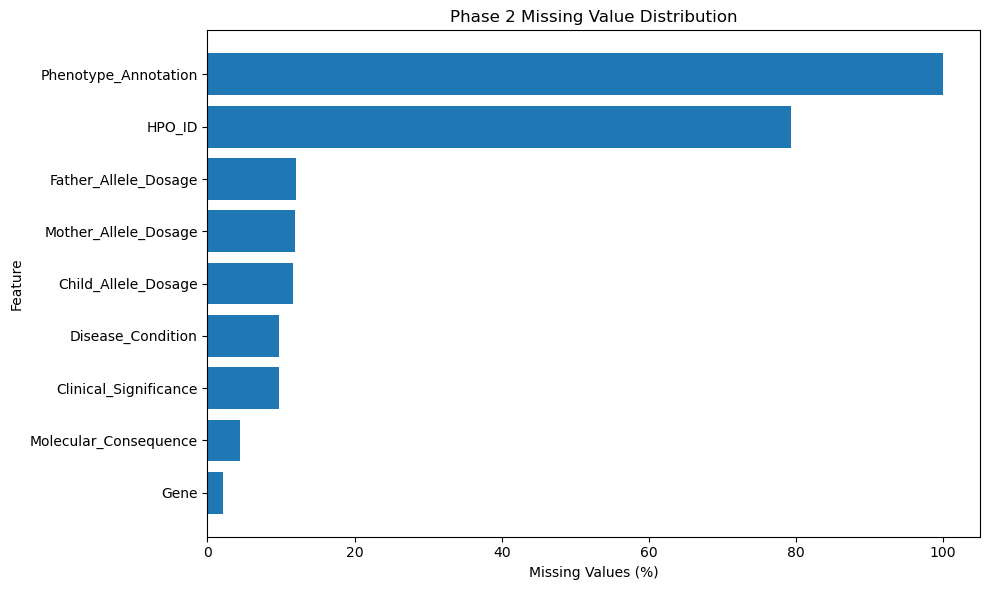

In [9]:
# VISUALIZE MISSING VALUES

missing_plot = missing_summary[
    missing_summary["Missing_Count"] > 0
].copy()

plt.figure(figsize=(10, 6))

plt.barh(
    missing_plot.index.astype(str),
    missing_plot["Missing_Percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Phase 2 Missing Value Distribution")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

GENOTYPE ANALYSIS

In [10]:
# ANALYZE MOTHER GENOTYPES

mother_genotypes = df_2["Mother_GT"].value_counts(dropna=False)

print(mother_genotypes)

Mother_GT
0/1    53480
1/1    35118
0/0    15822
./.    14136
1/0       53
Name: count, dtype: int64


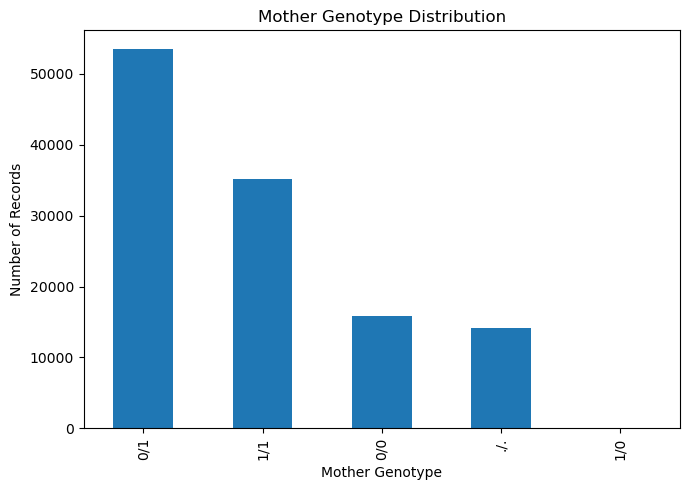

In [11]:
# VISUALIZE MOTHER GENOTYPES

plt.figure(figsize=(7, 5))

mother_genotypes.plot(kind="bar")

plt.xlabel("Mother Genotype")
plt.ylabel("Number of Records")
plt.title("Mother Genotype Distribution")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_mother_genotype_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ANALYZE FATHER GENOTYPES

father_genotypes = df_2["Father_GT"].value_counts(dropna=False)

print(father_genotypes)

Father_GT
0/1    52236
1/1    35402
0/0    16649
./.    14254
1/0       68
Name: count, dtype: int64


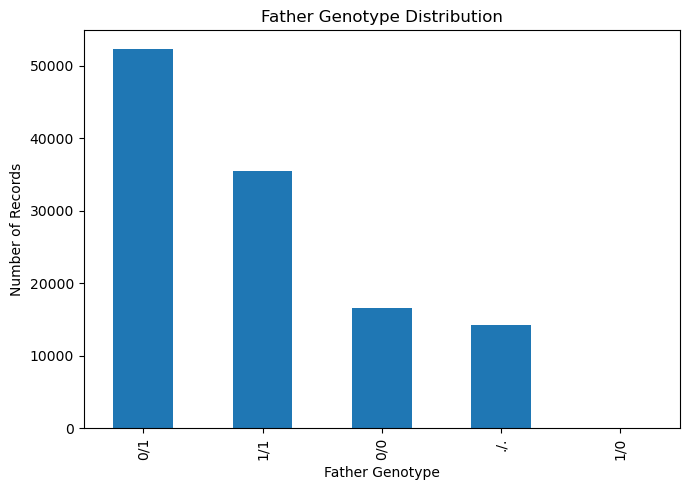

In [13]:
# VISUALIZE FATHER GENOTYPES

plt.figure(figsize=(7, 5))

father_genotypes.plot(kind="bar")

plt.xlabel("Father Genotype")
plt.ylabel("Number of Records")
plt.title("Father Genotype Distribution")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_father_genotype_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ANALYZE CHILD GENOTYPES

child_genotypes = df_2["Child_GT"].value_counts(dropna=False)

print(child_genotypes)

Child_GT
0/1    44738
1/1    34848
0/0    15399
./.    13819
1/0     9805
Name: count, dtype: int64


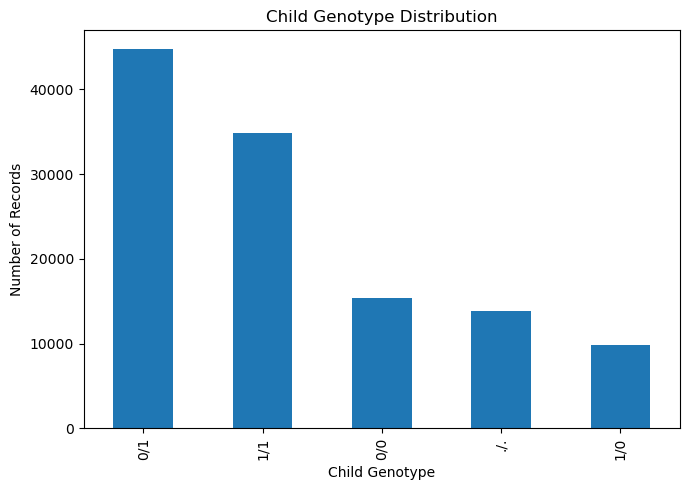

In [15]:
# VISUALIZE CHILD GENOTYPES

plt.figure(figsize=(7, 5))

child_genotypes.plot(kind="bar")

plt.xlabel("Child Genotype")
plt.ylabel("Number of Records")
plt.title("Child Genotype Distribution")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_child_genotype_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

MENDELIAN INHERITANCE ANALYSIS

In [16]:
# ANALYZE MENDELIAN STATUS

mendelian_counts = df_2["Mendelian_Status"].value_counts()

print(mendelian_counts)

Mendelian_Status
Compatible      87972
Undetermined    30383
Inconsistent      254
Name: count, dtype: int64


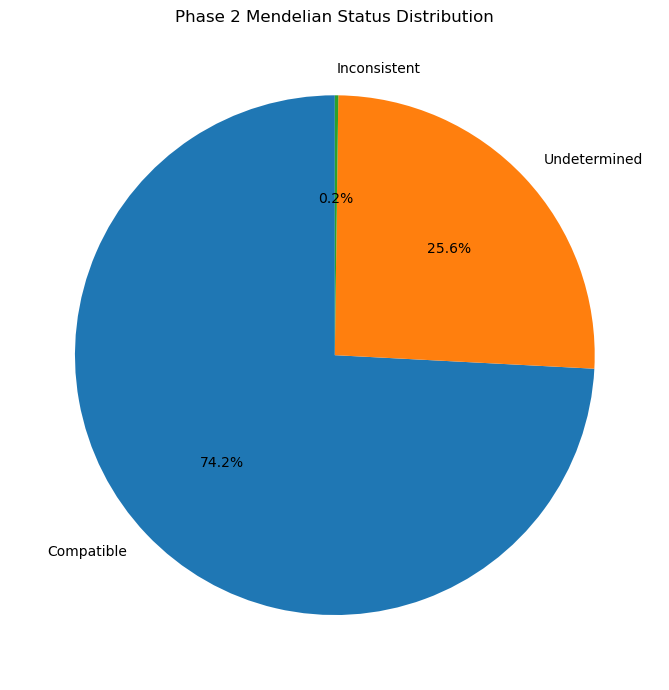

In [17]:
# VISUALIZE MENDELIAN STATUS

plt.figure(figsize=(7, 7))

mendelian_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Phase 2 Mendelian Status Distribution")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_mendelian_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

INHERITANCE SOURCE ANALYSIS

In [18]:
# ANALYZE INHERITANCE SOURCE

inheritance_counts = (
    df_2["Inheritance_Source"]
    .value_counts(dropna=False)
)

print(inheritance_counts)

Inheritance_Source
Both       53670
Unknown    30383
Neither    15525
Mother      9844
Father      9187
Name: count, dtype: int64


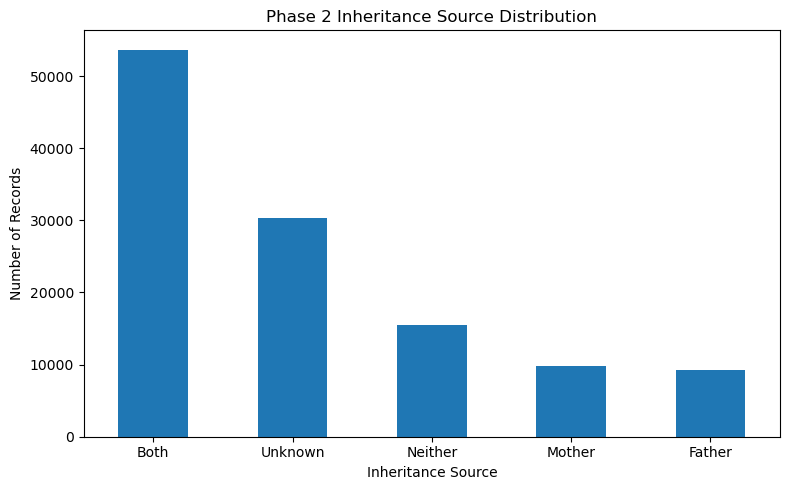

In [19]:
# VISUALIZE INHERITANCE SOURCE

plt.figure(figsize=(8, 5))

inheritance_counts.plot(kind="bar")

plt.xlabel("Inheritance Source")
plt.ylabel("Number of Records")
plt.title("Phase 2 Inheritance Source Distribution")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_inheritance_source_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

POSSIBLE CHILD GENOTYPE OUTCOMES

In [20]:
# ANALYZE POSSIBLE CHILD DOSAGES

possible_child_counts = (
    df_2["Possible_Child_Dosages"]
    .value_counts(dropna=False)
)

print(possible_child_counts)

Possible_Child_Dosages
Unknown    27881
0,1        26407
2          20340
1,2        19554
0,1,2      18529
1           5754
0            144
Name: count, dtype: int64


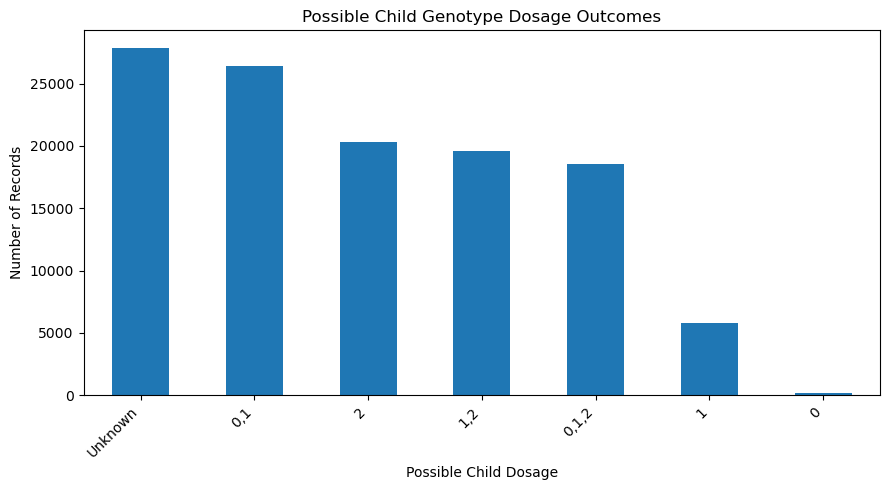

In [21]:
# VISUALIZE POSSIBLE CHILD DOSAGES

plt.figure(figsize=(9, 5))

possible_child_counts.plot(kind="bar")

plt.xlabel("Possible Child Dosage")
plt.ylabel("Number of Records")
plt.title("Possible Child Genotype Dosage Outcomes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_possible_child_dosage_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PARENTAL AND CHILD ALTERNATE-ALLELE ANALYSIS

In [22]:
# ANALYZE ALTERNATE ALLELE CARRIAGE

allele_features = [
    "Mother_Carries_Alternate",
    "Father_Carries_Alternate",
    "Child_Carries_Alternate",
    "Both_Parents_Carry_Alternate"
]

allele_summary = df_2[allele_features].sum()

print(allele_summary)

Mother_Carries_Alternate        88651
Father_Carries_Alternate        87706
Child_Carries_Alternate         89391
Both_Parents_Carry_Alternate    58423
dtype: int64


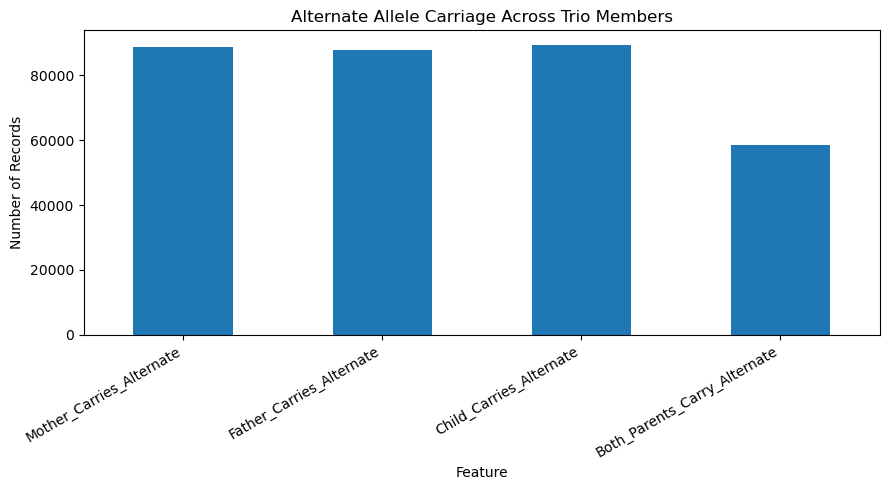

In [23]:
# VISUALIZE ALTERNATE ALLELE CARRIAGE

plt.figure(figsize=(9, 5))

allele_summary.plot(kind="bar")

plt.xlabel("Feature")
plt.ylabel("Number of Records")
plt.title("Alternate Allele Carriage Across Trio Members")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_alternate_allele_carriage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CLINICAL ANNOTATION ANALYSIS

In [24]:
# CHECK CLINICAL ANNOTATION COVERAGE

clinical_columns = [
    "Gene",
    "Molecular_Consequence",
    "Disease_Condition",
    "HPO_ID",
    "Phenotype_Annotation"
]

clinical_coverage = pd.DataFrame({
    "Available": df_2[clinical_columns].notna().sum(),
    "Missing": df_2[clinical_columns].isna().sum()
})

clinical_coverage

,Available,Missing
Gene,116170,2439
Molecular_Consequence,113285,5324
Disease_Condition,107052,11557
HPO_ID,24479,94130
Phenotype_Annotation,0,118609


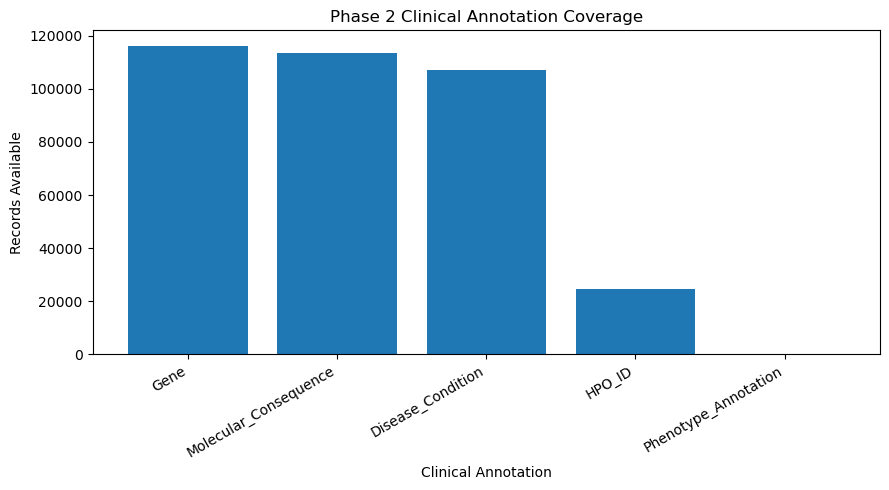

In [25]:
# VISUALIZE CLINICAL COVERAGE

plt.figure(figsize=(9, 5))

plt.bar(
    clinical_coverage.index.astype(str),
    clinical_coverage["Available"]
)

plt.xlabel("Clinical Annotation")
plt.ylabel("Records Available")
plt.title("Phase 2 Clinical Annotation Coverage")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_clinical_annotation_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

GENE ANALYSIS

In [26]:
# ANALYZE GENE ANNOTATIONS

print("Unique genes:", df_2["Gene"].nunique())
print("\nTop genes:")

print(
    df_2["Gene"]
    .value_counts()
    .head(15)
)

Unique genes: 12464

Top genes:
Gene
CNNM2:54805      514
SYNE1:23345      379
RYR2:6262        303
BRCA1:672        297
DOCK8:81704      278
DNAH11:8701      261
APC:324          248
COL5A1:1289      235
DNAH8:1769       231
BRCA2:675        225
ADGRV1:84059     220
COL4A1:1282      219
PIEZO2:63895     215
SYNE2:23224      208
DYNC2H1:79659    204
Name: count, dtype: int64


MOLECULAR CONSEQUENCE ANALYSIS

In [27]:
# ANALYZE MOLECULAR CONSEQUENCES

consequence_counts = (
    df_2["Molecular_Consequence"]
    .value_counts()
    .head(15)
)

print(consequence_counts)

Molecular_Consequence
SO:0001627|intron_variant                                                  80830
SO:0001819|synonymous_variant                                               8720
SO:0001624|3_prime_UTR_variant                                              7219
SO:0001583|missense_variant                                                 5216
SO:0001623|5_prime_UTR_variant                                              1366
SO:0001619|non-coding_transcript_variant,SO:0001819|synonymous_variant      1132
SO:0001619|non-coding_transcript_variant,SO:0001624|3_prime_UTR_variant     1102
SO:0001624|3_prime_UTR_variant,SO:0001627|intron_variant                     986
SO:0001623|5_prime_UTR_variant,SO:0001627|intron_variant                     792
SO:0001583|missense_variant,SO:0001627|intron_variant                        684
SO:0001627|intron_variant,SO:0001819|synonymous_variant                      651
SO:0001583|missense_variant,SO:0001619|non-coding_transcript_variant         598
SO:000

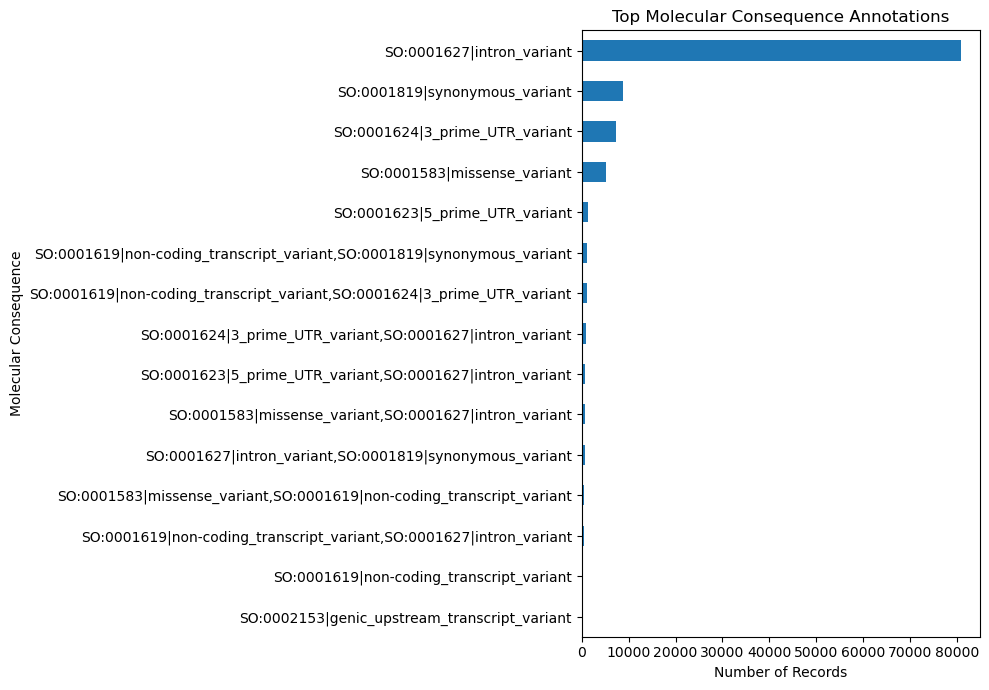

In [28]:
# VISUALIZE MOLECULAR CONSEQUENCES

plt.figure(figsize=(10, 7))

consequence_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Records")
plt.ylabel("Molecular Consequence")
plt.title("Top Molecular Consequence Annotations")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_molecular_consequence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

DISEASE / CONDITION ANALYSIS

In [29]:
# ANALYZE DISEASE ANNOTATIONS

print("Unique diseases:", df_2["Disease_Condition"].nunique())

print("\nTop disease annotations:")

print(
    df_2["Disease_Condition"]
    .value_counts()
    .head(15)
)

Unique diseases: 11608

Top disease annotations:
Disease_Condition
not_provided                                             66273
not_specified|not_provided                                2329
not_specified                                             2287
not_provided|not_specified                                1875
Familial_colorectal_cancer                                 211
Breast-ovarian_cancer,_familial,_susceptibility_to,_1      186
Tramadol_response                                          124
Breast-ovarian_cancer,_familial,_susceptibility_to,_2      119
MUC16-related_disorder                                     117
Retinitis_pigmentosa|not_provided                           72
FSIP2-related_disorder                                      60
ALPK2-related_disorder                                      55
Steel_syndrome|not_provided                                 53
Hydatidiform_mole,_recurrent,_1                             52
DCHS2-related_disorder                             

HPO ANNOTATION ANALYSIS

In [30]:
# ANALYZE HPO AVAILABILITY

hpo_counts = df_2["HPO_Available"].value_counts().sort_index()

print(hpo_counts)

print(
    "\nHPO available:",
    df_2["HPO_Available"].sum()
)

print(
    "HPO unavailable:",
    (df_2["HPO_Available"] == 0).sum()
)

HPO_Available
0    94130
1    24479
Name: count, dtype: int64

HPO available: 24479
HPO unavailable: 94130


In [31]:
# ANALYZE HPO COUNTS

print(df_2["HPO_Count"].describe())

count    118609.000000
mean          5.923168
std          16.190557
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         233.000000
Name: HPO_Count, dtype: float64


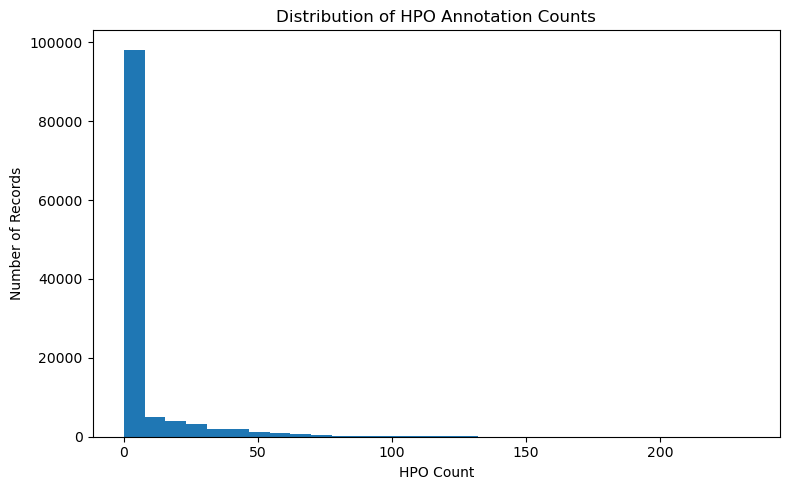

In [32]:
# VISUALIZE HPO COUNTS

plt.figure(figsize=(8, 5))

plt.hist(
    df_2["HPO_Count"],
    bins=30
)

plt.xlabel("HPO Count")
plt.ylabel("Number of Records")
plt.title("Distribution of HPO Annotation Counts")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase2_hpo_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CLINICAL INTERPRETATION DATASET

In [33]:
# CREATE CLINICAL INTERPRETATION DATASET

clinical_output = df_2[
    [
        "CHROM",
        "POS",
        "REF",
        "ALT",
        "Gene",
        "Molecular_Consequence",
        "Disease_Condition",
        "HPO_ID",
        "Phenotype_Annotation",
        "Mother_GT",
        "Father_GT",
        "Child_GT",
        "Mendelian_Status",
        "Inheritance_Source",
        "Possible_Child_Dosages"
    ]
].copy()

print("Clinical interpretation shape:", clinical_output.shape)

clinical_output.head()

Clinical interpretation shape: (118609, 15)


,CHROM,POS,REF,ALT,Gene,Molecular_Consequence,Disease_Condition,HPO_ID,Phenotype_Annotation,Mother_GT,Father_GT,Child_GT,Mendelian_Status,Inheritance_Source,Possible_Child_Dosages
0,1,713442,T,C,LOC100288069:100288069,None,None,None,NaN,0/1,0/0,0/0,Compatible,Neither,"0,1"
1,1,877831,T,C,SAMD11:148398,SO:0001583|missense_variant,not_provided,None,NaN,1/1,1/1,1/1,Compatible,Both,2
2,1,887560,A,C,NOC2L:26155,SO:0001627|intron_variant,None,None,NaN,1/1,1/1,1/1,Compatible,Both,2
3,1,899937,G,T,KLHL17:339451,SO:0001627|intron_variant,None,None,NaN,1/1,./.,./.,Undetermined,Unknown,Unknown
4,1,899942,G,A,KLHL17:339451,SO:0001627|intron_variant,None,None,NaN,1/1,./.,./.,Undetermined,Unknown,Unknown


In [34]:
# CHECK CLINICAL OUTPUT COVERAGE

print("Total records:", len(clinical_output))
print(
    "Records with disease:",
    clinical_output["Disease_Condition"].notna().sum()
)
print(
    "Records with HPO:",
    clinical_output["HPO_ID"].notna().sum()
)
print(
    "Records with gene:",
    clinical_output["Gene"].notna().sum()
)

Total records: 118609
Records with disease: 107052
Records with HPO: 24479
Records with gene: 116170


In [35]:
# SAVE CLINICAL INTERPRETATION DATASET

clinical_output.to_parquet(
    DATA_OUTPUT_DIR / "phase2_clinical_interpretation.parquet",
    index=False
)

print("Clinical interpretation dataset saved.")

Clinical interpretation dataset saved.


PHASE 2 SUMMARY METRICS

In [36]:
# CREATE SUMMARY METRICS

metrics = {
    "Total_Rows": len(df_2),
    "Compatible": (
        df_2["Mendelian_Status"] == "Compatible"
    ).sum(),
    "Undetermined": (
        df_2["Mendelian_Status"] == "Undetermined"
    ).sum(),
    "Inconsistent": (
        df_2["Mendelian_Status"] == "Inconsistent"
    ).sum(),
    "HPO_Available": df_2["HPO_ID"].notna().sum(),
    "Disease_Available": df_2["Disease_Condition"].notna().sum(),
    "Gene_Available": df_2["Gene"].notna().sum(),
    "Phenotype_Available": (
        df_2["Phenotype_Annotation"].notna()
    ).sum()
}

metrics

{'Total_Rows': 118609,
 'Compatible': np.int64(87972),
 'Undetermined': np.int64(30383),
 'Inconsistent': np.int64(254),
 'HPO_Available': np.int64(24479),
 'Disease_Available': np.int64(107052),
 'Gene_Available': np.int64(116170),
 'Phenotype_Available': np.int64(0)}

In [37]:
# DISPLAY SUMMARY METRICS

summary_df = pd.DataFrame([metrics])

summary_df

,Total_Rows,Compatible,Undetermined,Inconsistent,HPO_Available,Disease_Available,Gene_Available,Phenotype_Available
0,118609,87972,30383,254,24479,107052,116170,0


In [38]:
# SAVE SUMMARY METRICS

summary_df.to_csv(
    METRICS_DIR / "phase2_summary_metrics.csv",
    index=False
)

print("Phase 2 summary metrics saved.")

Phase 2 summary metrics saved.


# Final Phase 2 Summary

Phase 2 integrates trio genotype information with Mendelian inheritance
and clinical annotation data.

The analysis evaluates:

- Mother, father and child genotype patterns
- Mendelian inheritance compatibility
- Inheritance source
- Possible child genotype outcomes
- Alternate allele carriage
- Gene annotations
- Molecular consequences
- Disease and condition annotations
- HPO annotation availability

The resulting clinical interpretation dataset provides a structured
foundation for variant-level inheritance analysis and downstream
application development.

## Important Limitation

Phase 2 inheritance labels are derived from trio genotype relationships.
Therefore, any future machine-learning model must avoid using features
that directly encode the target outcome, in order to prevent target
leakage.

Further machine-learning refinement will be performed separately after
the inheritance prediction target and feature set have been formally
defined.